In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ipywidgets import interactive

# Load and Display Image

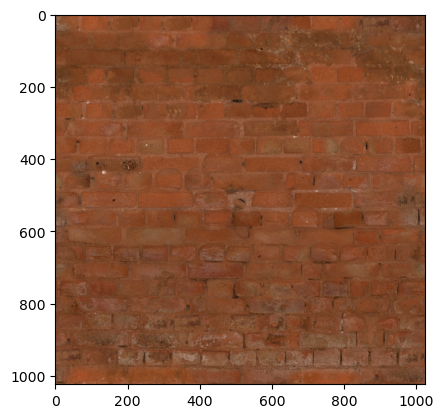

In [49]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

image = Image.open(material_textures_path + "albedo" + ext).convert("RGB").resize((1024, 1024))
image_array = np.asarray(image, dtype=np.float32) * (1/255.00)

fig, ax = plt.subplots()
ax.imshow(image_array)

plt.show()

In [44]:
block_size = 4
num_interp_values = 4
interp_values = np.zeros(num_interp_values)

for i in range(num_interp_values):
    interp_values[i] = (i * 1.0) / (num_interp_values - 1.0)

# Block Struct

In [8]:
class Block:
    def __init__(self):
        self.min_endpoint = np.ones((3), dtype=np.float32)
        self.max_endpoint = np.zeros((3), dtype=np.float32)
        
        self.indices = np.zeros((block_size, block_size, 1), dtype=np.uint8)

    def get_color_at_index(self, index):
        interp_value = interp_values[index]
        interp_color = (1.0 - interp_value) * self.min_endpoint + interp_value * self.max_endpoint

        return interp_color

    def get_color_at_coord(self, x, y):
        interp_index = self.indices[y][x]
        interp_color = self.get_color_at_index(interp_index)

        return interp_color

    def calc_endpoints(self, texture, x_offset, y_offset):
        for x in range(block_size):
            for y in range(block_size):
                color = texture[y + y_offset][x + x_offset]

                self.min_endpoint = np.minimum(color, self.min_endpoint)
                self.max_endpoint = np.maximum(color, self.max_endpoint)

    def calc_indices(self, texture, x_offset, y_offset):
        for x in range(block_size):
            for y in range(block_size):
                shortest_distance = 100.0
                closest_index = 0

                original_color = texture[y + y_offset][x + x_offset]

                for i in range(interp_values.shape[0]):
                    interp_value = interp_values[i]
                    interp_color = (1.0 - interp_value) * self.min_endpoint + interp_value * self.max_endpoint

                    distance = abs(np.linalg.norm(interp_color - original_color))
            
                    if distance < shortest_distance:
                        closest_index = i
                        shortest_distance = distance

                self.indices[y][x] = closest_index

# Generate Block Image for Reference

In [23]:
block_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

x_offset = 100
y_offset = 440

max_x_offset = image_array.shape[0] - block_size
max_y_offset = image_array.shape[1] - block_size

x_offset = max(0, min(max_x_offset, x_offset))
y_offset = max(0, min(max_y_offset, y_offset))

for x in range(block_size):
    for y in range(block_size):
        block_array[y][x] = image_array[y+y_offset][x+x_offset]

# Compress Test Block

In [24]:
test_block = Block()

test_block.calc_endpoints(image_array, x_offset, y_offset)

test_block.calc_indices(image_array, x_offset, y_offset)

# Decompress Test Block

In [25]:
decompressed_block_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

for x in range(block_size):
    for y in range(block_size):
        decompressed_block_array[y][x] = test_block.get_color_at_coord(x, y)

# Display Difference

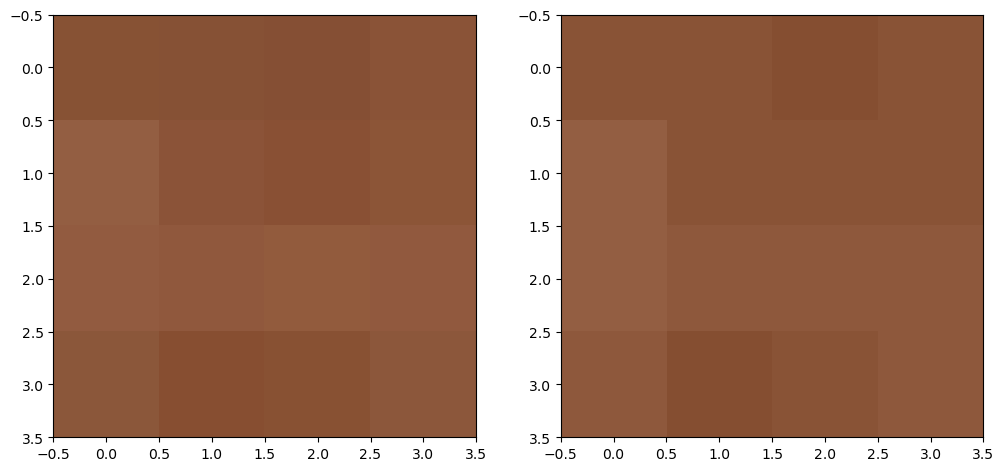

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(block_array)
axes[1].imshow(decompressed_block_array)

plt.show()

# Plot Colors, Enp

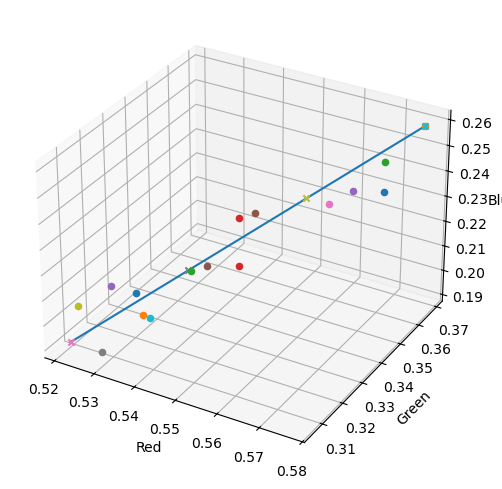

In [13]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(projection='3d')
ax.set_ybound(lower=0.0, upper=1.0)
ax.set_xbound(lower=0.0, upper=1.0)
ax.set_zbound(lower=0.0, upper=1.0)

for x in range(block_size):
    for y in range(block_size):
        ax.scatter(block_array[y][x][0], block_array[y][x][1], block_array[y][x][2])

for i in range(num_interp_values):
    interp_color = test_block.get_color_at_index(i)

    ax.scatter(interp_color[0], interp_color[1], interp_color[2], marker='x')

x_points = [test_block.min_endpoint[0], test_block.max_endpoint[0]]
y_points = [test_block.min_endpoint[1], test_block.max_endpoint[1]]
z_points = [test_block.min_endpoint[2], test_block.max_endpoint[2]]

ax.plot(x_points, y_points, z_points)

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

plt.show()

# Compress Full Image Prototyping

In [51]:
def calc_endpoints(endpoints, texture, x_offset, y_offset):
    endpoints[0] = np.array([1.0, 1.0, 1.0])
    endpoints[1] = np.array([0.0, 0.0, 0.0])
    
    for x in range(block_size):
        for y in range(block_size):
            color = texture[y + y_offset][x + x_offset]
                
            endpoints[0] = np.minimum(color, endpoints[0])
            endpoints[1] = np.maximum(color, endpoints[1])

def calc_indices(endpoints, indices, texture, x_offset, y_offset):
    for x in range(block_size):
        for y in range(block_size):
            shortest_distance = 100.0
            closest_index = 0

            original_color = texture[y + y_offset][x + x_offset]

            for i in range(interp_values.shape[0]):
                interp_value = interp_values[i]
                interp_color = (1.0 - interp_value) * endpoints[0] + interp_value * endpoints[1]

                distance = abs(np.linalg.norm(interp_color - original_color))
            
                if distance < shortest_distance:
                    closest_index = i
                    shortest_distance = distance

            indices[y + y_offset][x + x_offset] = closest_index

def get_color_at_index(endpoints, block_x_offset, block_y_offset, index):
    block_endpoints = endpoints[block_y_offset][block_x_offset]
    
    interp_value = interp_values[index]
    interp_color = (1.0 - interp_value) * block_endpoints[0] + interp_value * block_endpoints[1]

    return interp_color

def get_color_at_coord(endpoints, indices, pixel_x_offset, pixel_y_offset):
    
    block_x_index = int(pixel_x_offset / block_size)
    block_y_index = int(pixel_y_offset / block_size)
    
    interp_index = indices[pixel_y_offset][pixel_x_offset]
    interp_color = get_color_at_index(endpoints, block_x_index, block_y_index, interp_index)
    
    return interp_color

In [52]:
if image_array.shape[0] % block_size != 0:
    print("block size doesn't fit evenly into texture")

texture_width_in_blocks = int(image_array.shape[0] / block_size)

endpoints = np.zeros((texture_width_in_blocks, texture_width_in_blocks, 2, 3), dtype=np.float32)
indices = np.zeros((image_array.shape[0], image_array.shape[0], 1), dtype=np.int8)

# this stores it in column major which is a bit confusing but at least it matches the texture itself
for block_x_index in range(texture_width_in_blocks):
    for block_y_index in range(texture_width_in_blocks):
        pixel_x_offset = block_x_index * block_size
        pixel_y_offset = block_y_index * block_size

        block_endpoints = endpoints[block_y_index][block_x_index]

        calc_endpoints(block_endpoints, image_array, pixel_x_offset, pixel_y_offset)
        calc_indices(block_endpoints, indices, image_array, pixel_x_offset, pixel_y_offset)

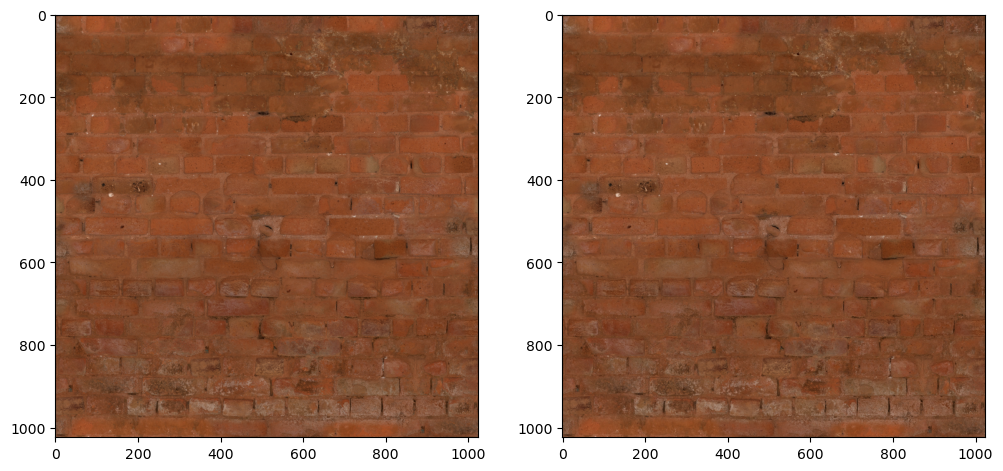

[0.         0.33333333 0.66666667 1.        ]


In [53]:
decompressed_image_array = np.zeros(image_array.shape)

for x in range(image_array.shape[0]):
    for y in range(image_array.shape[0]):
        decompressed_image_array[y][x] = get_color_at_coord(endpoints, indices, x, y)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(image_array)
axes[1].imshow(decompressed_image_array)

plt.show()

print(interp_values)

In [54]:
def display_block(block_x_offset, block_y_offset):
    uncomp_block_temp_array = np.zeros((block_size, block_size, 3), dtype=np.float32)
    decomp_block_temp_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

    pixel_x_offset = block_x_offset * block_size
    pixel_y_offset = block_y_offset * block_size
    
    max_x_offset = image_array.shape[0] - block_size
    max_y_offset = image_array.shape[1] - block_size

    pixel_x_offset = max(0, min(max_x_offset, pixel_x_offset))
    pixel_y_offset = max(0, min(max_y_offset, pixel_y_offset))

    for x in range(block_size):
        for y in range(block_size):
            uncomp_block_temp_array[y][x] = image_array[y+pixel_y_offset][x+pixel_x_offset]
            decomp_block_temp_array[y][x] = decompressed_image_array[y+pixel_y_offset][x+pixel_x_offset]

    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    axes[0].imshow(uncomp_block_temp_array)
    axes[1].imshow(decomp_block_temp_array)

    plt.show()

    # display graph
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(projection='3d')
    ax.set_ybound(lower=0.0, upper=1.0)
    ax.set_xbound(lower=0.0, upper=1.0)
    ax.set_zbound(lower=0.0, upper=1.0)

    for x in range(block_size):
        for y in range(block_size):
            ax.scatter(image_array[y+pixel_y_offset][x+pixel_x_offset][0], image_array[y+pixel_y_offset][x+pixel_x_offset][1], image_array[y+pixel_y_offset][x+pixel_x_offset][2])

    for i in range(num_interp_values):
        interp_color = get_color_at_index(endpoints, block_x_offset, block_y_offset, i)

        ax.scatter(interp_color[0], interp_color[1], interp_color[2], marker='x')

    block_endpoints = endpoints[block_y_offset][block_x_offset]
    
    x_points = [block_endpoints[0][0], block_endpoints[1][0]]
    y_points = [block_endpoints[0][1], block_endpoints[1][1]]
    z_points = [block_endpoints[0][2], block_endpoints[1][2]]

    ax.plot(x_points, y_points, z_points)

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')

    plt.show()

interactive_block = interactive(display_block, block_x_offset=(0, texture_width_in_blocks - 1), block_y_offset=(0, texture_width_in_blocks - 1))
interactive_block

interactive(children=(IntSlider(value=127, description='block_x_offset', max=255), IntSlider(value=127, descri…